# Classificação Supervisionada com Fuzzy C-Means no Dataset Dry Bean

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Fuzzy C-Means, aplicado ao dataset Dry Bean. Todas as etapas são explicadas e o código é comentado para facilitar o entendimento.

## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, visualização e implementação do Fuzzy C-Means.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import skfuzzy as fuzz
import os

# Garante que a pasta 'img' existe
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Pré-processamento dos Dados

Carregamos o dataset Dry Bean, removemos valores ausentes, codificamos variáveis categóricas e normalizamos os dados.

In [2]:
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')
bean_df = bean_df.dropna()

print('Amostra dos dados originais:')
display(bean_df.head())


Amostra dos dados originais:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
for col in bean_df.select_dtypes(include='object').columns:
    bean_df[col] = LabelEncoder().fit_transform(bean_df[col].astype(str))
X = bean_df.drop('Class', axis=1).values
y = bean_df['Class'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)



## 3. Divisão dos Dados em Treino e Teste

Dividimos o conjunto de dados em 70% para treinamento e 30% para teste, garantindo a estratificação das classes.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 4. Definição do Número de Clusters (Método do Cotovelo)

Utilizamos o método do cotovelo para determinar o número ideal de clusters para o Fuzzy C-Means, usando o coeficiente de partição.

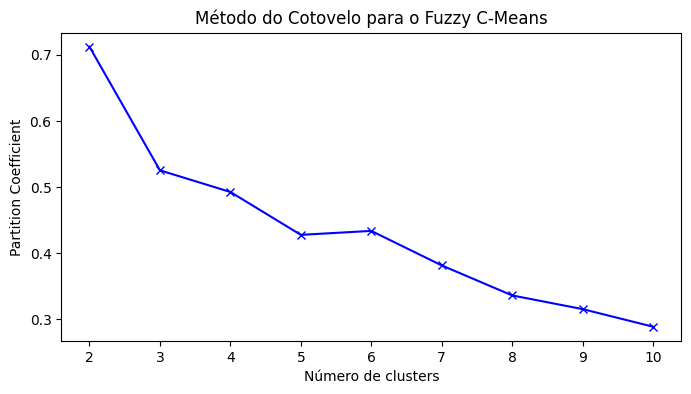

In [5]:
partition_coeffs = []
K = range(2, 11)
for k in K:
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_train.T, c=k, m=2, error=0.005, maxiter=1000, seed=42)
    pc = np.sum(u ** 2) / u.shape[1]
    partition_coeffs.append(pc)

plt.figure(figsize=(8,4))
plt.plot(K, partition_coeffs, 'bx-')
plt.xlabel('Número de clusters')
plt.ylabel('Partition Coefficient')
plt.title('Método do Cotovelo para o Fuzzy C-Means')
plt.savefig('img/cmeans_drybean_elbow.png')
plt.show()

## 5. Implementação do Classificador Fuzzy C-Means Supervisionado

O classificador associa cada cluster ao rótulo mais frequente no conjunto de treino.

In [6]:
class FuzzyCMeansSupervisionado:
    def __init__(self, n_clusters=2, m=2, random_state=0):
        self.n_clusters = n_clusters
        self.m = m
        self.random_state = random_state
        self.centers_ = None
        self.cluster_labels_ = None

    def fit(self, X, y):
        cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
            X.T, c=self.n_clusters, m=self.m, error=0.005, maxiter=1000, seed=self.random_state)
        self.centers_ = cntr
        labels = np.argmax(u, axis=0)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (labels == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        u, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
            X.T, self.centers_, m=self.m, error=0.005, maxiter=1000)
        clusters = np.argmax(u, axis=0)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 6. Treinamento e Avaliação do Classificador

Treinamos o classificador no conjunto de treino e avaliamos no conjunto de teste, mostrando acurácia e matriz de confusão.

Acurácia: 0.8484
Matriz de Confusão:
[[308   0  50   0   3  10  26]
 [  0 157   0   0   0   0   0]
 [ 84   0 395   0   7   2   1]
 [  0   0   0 845   2  35 182]
 [  7   0  38   0 520   0  13]
 [  0   0   0  20   0 557  31]
 [ 21   0   6  51  22   8 683]]


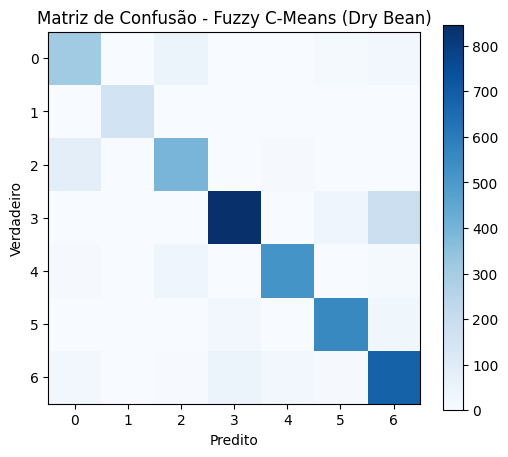

In [7]:
n_clusters = 7  # Ajuste conforme o gráfico do cotovelo

clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X_train, y_train)

acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Fuzzy C-Means (Dry Bean)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig('img/cmeans_drybean_confusion_matrix.png')
plt.show()

## 7. Repetição dos Experimentos

Repita o experimento 30 vezes, variando a semente, e salve as acurácias para análise estatística.

Acurácia média: 0.8496
Desvio padrão: 0.0069


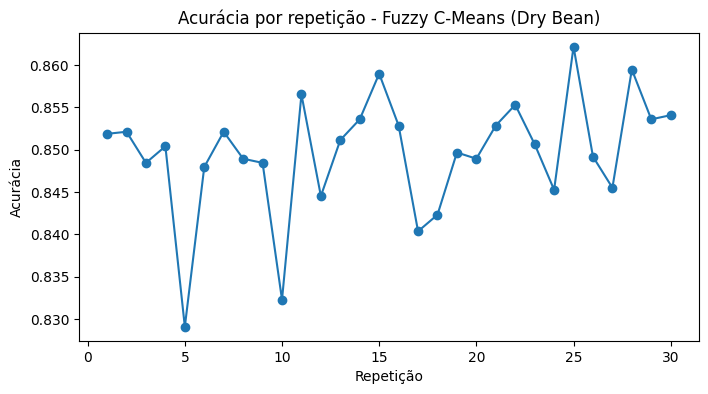

In [8]:
acuracias = []
# Garante que a pasta 'img' existe
import os
os.makedirs('img', exist_ok=True)
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    acc, _ = clf.evaluate(X_test, y_test)
    acuracias.append(acc)

acuracias = np.array(acuracias)
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão: {acuracias.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - Fuzzy C-Means (Dry Bean)')
plt.savefig('img/cmeans_drybean_accuracy_repetitions.png')
np.save('img/cmeans_drybean_accuracies.npy', acuracias)
np.savetxt('img/cmeans_drybean_accuracies.csv', acuracias, delimiter=',')
plt.show()

MSE médio: 1.3029
Desvio padrão do MSE: 0.0660


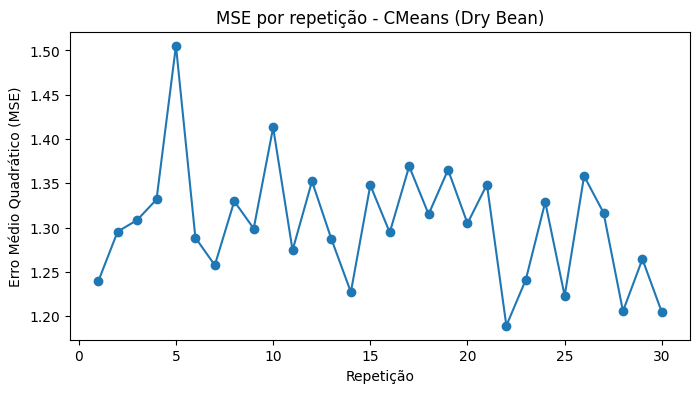

In [9]:
from sklearn.metrics import mean_squared_error

mse_list = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)

mse_array = np.array(mse_list)
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - CMeans (Dry Bean)')
plt.savefig('img/cmeans_drybean_mse_repetitions.png')
plt.show()

# Salvar MSE para análise posterior
np.save('img/cmeans_drybean_mse_repetitions.npy', mse_array)
np.savetxt('img/cmeans_drybean_mse_repetitions.csv', mse_array, delimiter=',')

## 8. Análise dos Resultados

Comente os resultados obtidos, destacando a acurácia média, o desvio padrão e possíveis dificuldades do classificador Fuzzy C-Means no dataset Dry Bean.

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

accuracies = []
precisions_macro = []
recalls_macro = []
f1s_macro = []
precisions_micro = []
recalls_micro = []
f1s_micro = []
cms = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions_macro.append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    recalls_macro.append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    f1s_macro.append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    precisions_micro.append(precision_score(y_test, y_pred, average='micro', zero_division=0))
    recalls_micro.append(recall_score(y_test, y_pred, average='micro', zero_division=0))
    f1s_micro.append(f1_score(y_test, y_pred, average='micro', zero_division=0))
    cms.append(confusion_matrix(y_test, y_pred))

print('Acurácia média:', np.mean(accuracies))
print('Precisão macro média:', np.mean(precisions_macro))
print('Recall macro médio:', np.mean(recalls_macro))
print('F1-score macro médio:', np.mean(f1s_macro))
print('Precisão micro média:', np.mean(precisions_micro))
print('Recall micro médio:', np.mean(recalls_micro))
print('F1-score micro médio:', np.mean(f1s_micro))
print('Matriz de confusão média:')
print(np.mean(cms, axis=0))

Acurácia média: 0.8496082272282076
Precisão macro média: 0.8627225400955324
Recall macro médio: 0.8660366581364773
F1-score macro médio: 0.8626844385734757
Precisão micro média: 0.8496082272282076
Recall micro médio: 0.8496082272282076
F1-score micro médio: 0.8496082272282076
Matriz de confusão média:
[[3.16066667e+02 2.00000000e-01 4.66666667e+01 0.00000000e+00
  2.83333333e+00 6.80000000e+00 2.44333333e+01]
 [0.00000000e+00 1.57000000e+02 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.65666667e+01 0.00000000e+00 3.91933333e+02 0.00000000e+00
  5.33333333e+00 6.00000000e-01 4.56666667e+00]
 [6.00000000e-01 0.00000000e+00 6.66666667e-02 8.57166667e+02
  3.36666667e+00 3.64666667e+01 1.66333333e+02]
 [6.40000000e+00 0.00000000e+00 4.90666667e+01 7.66666667e-01
  5.08866667e+02 0.00000000e+00 1.29000000e+01]
 [6.66666667e-01 0.00000000e+00 4.00000000e-01 1.82666667e+01
  0.00000000e+00 5.58566667e+02 3.01000000e+01]
 [2.27666667e+01 0.00000000e+00 4.366

## 9. Cálculo e Interpretação das Métricas de Avaliação
 
Nesta etapa, calculamos as principais métricas de avaliação para problemas multiclasse:
- **Acurácia**: proporção de acertos totais.
- **Precisão, Recall, F1-score (macro/micro)**: médias das métricas considerando todas as classes.
- **Matriz de confusão média**: média das matrizes de confusão das 30 execuções.

Essas métricas permitem avaliar o desempenho do classificador em cenários com múltiplas classes, mostrando não só o acerto global, mas também o equilíbrio entre as classes.

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
def calcular_metricas_multiclasse(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    # Especificidade média: média das especificidades de cada classe
    especificidades = []
    for i in range(cm.shape[0]):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        especificidades.append(especificidade)
    especificidade_media = np.mean(especificidades)
    return acc, prec, rec, especificidade_media, f1, cm

# Repetição para obter métricas médias
accs, precs, recs, especificidades, f1s, cms = [], [], [], [], [], []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc, prec, rec, esp, f1, cm = calcular_metricas_multiclasse(y_test, y_pred)
    accs.append(acc)
    precs.append(prec)
    recs.append(rec)
    especificidades.append(esp)
    f1s.append(f1)
    cms.append(cm)

print(f'Acurácia média: {np.mean(accs):.4f}')
print(f'Precisão média: {np.mean(precs):.4f}')
print(f'Recall médio: {np.mean(recs):.4f}')
print(f'Especificidade média: {np.mean(especificidades):.4f}')
print(f'F1-score médio: {np.mean(f1s):.4f}')
print('Matriz de confusão média:')
print(np.mean(cms, axis=0).round(2))

Acurácia média: 0.8496
Precisão média: 0.8627
Recall médio: 0.8660
Especificidade média: 0.9742
F1-score médio: 0.8627
Matriz de confusão média:
[[3.1607e+02 2.0000e-01 4.6670e+01 0.0000e+00 2.8300e+00 6.8000e+00
  2.4430e+01]
 [0.0000e+00 1.5700e+02 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00]
 [8.6570e+01 0.0000e+00 3.9193e+02 0.0000e+00 5.3300e+00 6.0000e-01
  4.5700e+00]
 [6.0000e-01 0.0000e+00 7.0000e-02 8.5717e+02 3.3700e+00 3.6470e+01
  1.6633e+02]
 [6.4000e+00 0.0000e+00 4.9070e+01 7.7000e-01 5.0887e+02 0.0000e+00
  1.2900e+01]
 [6.7000e-01 0.0000e+00 4.0000e-01 1.8270e+01 0.0000e+00 5.5857e+02
  3.0100e+01]
 [2.2770e+01 0.0000e+00 4.3700e+00 5.1970e+01 2.6070e+01 5.6300e+00
  6.8020e+02]]


## 9. Cálculo das Principais Métricas de Avaliação
Nesta etapa, calculamos e exibimos as principais métricas de avaliação do classificador: acurácia, precisão, recall, especificidade, F1-score e matriz de confusão média. Essas métricas permitem uma análise quantitativa detalhada do desempenho do modelo em múltiplas classes.